<a href="https://colab.research.google.com/github/SP-2112/Arcadia-Phoenix-GameDev/blob/main/Code_Notebooks/07_XGBoost_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://raw.githubusercontent.com/UtkarshRaj130/Advanced_Soybean_Agricultural_Dataset_Analysis/refs/heads/main/Dataset/Optimal_Clusters_datasets/labeled_clusters_KMeans_k_2_sel.csv
# dataset on kmeans - 2

--2025-04-14 09:35:18--  https://raw.githubusercontent.com/UtkarshRaj130/Advanced_Soybean_Agricultural_Dataset_Analysis/refs/heads/main/Dataset/Optimal_Clusters_datasets/labeled_clusters_KMeans_k_2_sel.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4497 (4.4K) [text/plain]
Saving to: ‘labeled_clusters_KMeans_k_2_sel.csv.1’

labeled_clusters_KM 100%[===================>]   4.39K  --.-KB/s    in 0s      

2025-04-14 09:35:18 (42.8 MB/s) - ‘labeled_clusters_KMeans_k_2_sel.csv.1’ saved [4497/4497]



In [ ]:
!wget https://raw.githubusercontent.com/UtkarshRaj130/Advanced_Soybean_Agricultural_Dataset_Analysis/refs/heads/main/Dataset/Optimal_Clusters_datasets/labeled_clusters_KMedoids_k_2_sel.csv
# dataset on kmedoids - 2

--2025-04-14 09:35:18--  https://raw.githubusercontent.com/UtkarshRaj130/Advanced_Soybean_Agricultural_Dataset_Analysis/refs/heads/main/Dataset/Optimal_Clusters_datasets/labeled_clusters_KMedoids_k_2_sel.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4499 (4.4K) [text/plain]
Saving to: ‘labeled_clusters_KMedoids_k_2_sel.csv’

labeled_clusters_KM 100%[===================>]   4.39K  --.-KB/s    in 0s      

2025-04-14 09:35:18 (34.7 MB/s) - ‘labeled_clusters_KMedoids_k_2_sel.csv’ saved [4499/4499]



In [ ]:
!wget https://raw.githubusercontent.com/UtkarshRaj130/Advanced_Soybean_Agricultural_Dataset_Analysis/refs/heads/main/Dataset/3_one_hot_encoded.csv
# input dataset

--2025-04-14 09:35:18--  https://raw.githubusercontent.com/UtkarshRaj130/Advanced_Soybean_Agricultural_Dataset_Analysis/refs/heads/main/Dataset/3_one_hot_encoded.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13442 (13K) [text/plain]
Saving to: ‘3_one_hot_encoded.csv’

3_one_hot_encoded.c 100%[===================>]  13.13K  --.-KB/s    in 0.001s  

2025-04-14 09:35:18 (21.2 MB/s) - ‘3_one_hot_encoded.csv’ saved [13442/13442]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.feature_selection import mutual_info_regression

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.model_selection import ParameterGrid

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Data of Kmeans - 2 Clustering

In [ ]:
data_kmeans_2=pd.read_csv('labeled_clusters_KMeans_k_2_sel.csv')

In [ ]:
data_kmeans_2

,Prod_Label_KMeans_k=2_sel,Sugars (Su),Weight of 300 Seeds (W3S),Seed Yield per Unit Area (SYUA),Number of Seeds per Pod (NSP),Protein Percentage (PPE),Protein Content (PCO),Number of Pods (NP)
0,0,0.433,33.6,5567.4,1.86,33.2,0.82,130.3
1,0,0.334,34.4,2245.5,1.87,38.5,0.13,132.0
2,0,0.490,35.2,4326.7,2.04,33.6,0.15,150.0
3,1,0.163,52.3,6214.5,2.20,33.5,0.14,140.8
4,0,0.795,31.2,3897.8,1.88,39.6,0.60,175.6
...,...,...,...,...,...,...,...,...
103,0,0.663,31.2,4472.7,2.60,39.7,0.32,209.0
104,1,0.165,34.5,5643.7,2.60,33.6,0.36,160.0
105,0,1.115,37.2,3067.1,1.80,37.2,1.15,148.3
106,0,0.295,35.3,3112.2,2.10,32.3,0.17,156.0


# One Hot Encoded Data

In [ ]:
data_original=pd.read_csv('3_one_hot_encoded.csv')
data_original=data_original.drop(columns=['Parameters','Random '])

In [ ]:
data_original

,Plant Height (PH),Number of Pods (NP),Biological Weight (BW),Sugars (Su),Relative Water Content in Leaves (RWCL),ChlorophyllA663,Chlorophyllb649,Protein Percentage (PPE),Weight of 300 Seeds (W3S),Leaf Area Index (LAI),...,Number of Seeds per Pod (NSP),Protein Content (PCO),C_2,S_2,S_3,G_2,G_3,G_4,G_5,G_6
0,50.5,130.3,111,0.433,0.732,1.4,3.1,33.2,33.6,0.08,...,1.86,0.82,False,False,False,False,False,False,True,False
1,44.5,132.0,80,0.334,0.674,7.1,2.2,38.5,34.4,0.09,...,1.87,0.13,True,False,True,False,False,True,False,False
2,52.2,150.0,83,0.490,0.677,1.8,1.3,33.6,35.2,0.07,...,2.04,0.15,True,False,False,False,False,False,False,True
3,50.5,140.8,66,0.163,0.745,1.1,3.0,33.5,52.3,0.09,...,2.20,0.14,False,False,False,False,False,False,False,False
4,49.2,175.6,73,0.795,0.725,7.5,2.1,39.6,31.2,0.10,...,1.88,0.60,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,44.0,209.0,132,0.663,0.875,9.0,1.3,39.7,31.2,0.06,...,2.60,0.32,False,True,False,False,True,False,False,False
104,53.3,160.0,130,0.165,0.651,1.8,3.2,33.6,34.5,0.10,...,2.60,0.36,False,False,True,True,False,False,False,False
105,50.2,148.3,151,1.115,0.683,6.1,1.2,37.2,37.2,0.10,...,1.80,1.15,True,False,False,False,False,False,True,False
106,52.2,156.0,66,0.295,0.632,6.9,1.1,32.3,35.3,0.09,...,2.10,0.17,True,True,False,False,False,True,False,False


# Data using Kmedoid - 2

In [ ]:
data_kmedoid_2=pd.read_csv('labeled_clusters_KMedoids_k_2_sel.csv')

In [ ]:
data_kmedoid_2

,Prod_Label_KMedoids_k=2_sel,Sugars (Su),Weight of 300 Seeds (W3S),Seed Yield per Unit Area (SYUA),Number of Seeds per Pod (NSP),Protein Percentage (PPE),Protein Content (PCO),Number of Pods (NP)
0,0,0.433,33.6,5567.4,1.86,33.2,0.82,130.3
1,1,0.334,34.4,2245.5,1.87,38.5,0.13,132.0
2,0,0.490,35.2,4326.7,2.04,33.6,0.15,150.0
3,1,0.163,52.3,6214.5,2.20,33.5,0.14,140.8
4,1,0.795,31.2,3897.8,1.88,39.6,0.60,175.6
...,...,...,...,...,...,...,...,...
103,1,0.663,31.2,4472.7,2.60,39.7,0.32,209.0
104,1,0.165,34.5,5643.7,2.60,33.6,0.36,160.0
105,0,1.115,37.2,3067.1,1.80,37.2,1.15,148.3
106,0,0.295,35.3,3112.2,2.10,32.3,0.17,156.0


In [ ]:
def target_data_retreival(data):
  return pd.DataFrame(data[data.columns[0]])

In [ ]:
data_Y_kmeans=target_data_retreival(data_kmeans_2)
data_Y_kmedoid=target_data_retreival(data_kmedoid_2)

In [ ]:
data_Y_kmeans

,Prod_Label_KMeans_k=2_sel
0,0
1,0
2,0
3,1
4,0
...,...
103,0
104,1
105,0
106,0


In [ ]:
data_Y_kmeans.value_counts()

,count
Prod_Label_KMeans_k=2_sel,
0,72
1,36


In [ ]:
data_Y_kmedoid

,Prod_Label_KMedoids_k=2_sel
0,0
1,1
2,0
3,1
4,1
...,...
103,1
104,1
105,0
106,0


In [ ]:
data_Y_kmedoid.value_counts()

,count
Prod_Label_KMedoids_k=2_sel,
1,65
0,43


In [ ]:
def input_data_retrieval(data):
  columns=data.columns
  dataX=pd.DataFrame(data[columns[-8:]])
  for i in columns[-8:]:
    dataX[i]=dataX[i].map({False:0,True:1})
  dataX1=pd.DataFrame(data[columns[1:-8]])
  dataX2=pd.DataFrame(dataX1)
  dataX2[columns[-8:]]=dataX
  return dataX,dataX1,dataX2

In [ ]:
data_X,data_X1,data_X2=input_data_retrieval(data_original)
# data_X3,data_X4,data_X5=input_data_retrieval(data_kmedoid_2)

# Datasets convention
data_X - dataframe with only the parameters C,G and S <br>
data_X1 - dataframe with all parameters other than C, G and S <br>
data_X2 - dataframe with all parameters

In [ ]:
data_X2

,Number of Pods (NP),Biological Weight (BW),Sugars (Su),Relative Water Content in Leaves (RWCL),ChlorophyllA663,Chlorophyllb649,Protein Percentage (PPE),Weight of 300 Seeds (W3S),Leaf Area Index (LAI),Seed Yield per Unit Area (SYUA),Number of Seeds per Pod (NSP),Protein Content (PCO),C_2,S_2,S_3,G_2,G_3,G_4,G_5,G_6
0,130.3,111,0.433,0.732,1.4,3.1,33.2,33.6,0.08,5567.4,1.86,0.82,0,0,0,0,0,0,1,0
1,132.0,80,0.334,0.674,7.1,2.2,38.5,34.4,0.09,2245.5,1.87,0.13,1,0,1,0,0,1,0,0
2,150.0,83,0.490,0.677,1.8,1.3,33.6,35.2,0.07,4326.7,2.04,0.15,1,0,0,0,0,0,0,1
3,140.8,66,0.163,0.745,1.1,3.0,33.5,52.3,0.09,6214.5,2.20,0.14,0,0,0,0,0,0,0,0
4,175.6,73,0.795,0.725,7.5,2.1,39.6,31.2,0.10,3897.8,1.88,0.60,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,209.0,132,0.663,0.875,9.0,1.3,39.7,31.2,0.06,4472.7,2.60,0.32,0,1,0,0,1,0,0,0
104,160.0,130,0.165,0.651,1.8,3.2,33.6,34.5,0.10,5643.7,2.60,0.36,0,0,1,1,0,0,0,0
105,148.3,151,1.115,0.683,6.1,1.2,37.2,37.2,0.10,3067.1,1.80,1.15,1,0,0,0,0,0,1,0
106,156.0,66,0.295,0.632,6.9,1.1,32.3,35.3,0.09,3112.2,2.10,0.17,1,1,0,0,0,1,0,0


# Test train split

## Kmeans dataset

In [ ]:
# C, G, S
data_X_train_kmeans,data_X_test_kmeans,data_Y_train_kmeans,data_Y_test_kmeans=train_test_split(data_X,data_Y_kmeans,test_size=0.2,random_state=42)

# Output parameters
data_X1_train_kmeans,data_X1_test_kmeans,data_Y1_train_kmeans,data_Y1_test_kmeans=train_test_split(data_X1,data_Y_kmeans,test_size=0.2,random_state=42)

# All parameters
data_X2_train_kmeans,data_X2_test_kmeans,data_Y2_train_kmeans,data_Y2_test_kmeans=train_test_split(data_X2,data_Y_kmeans,test_size=0.2,random_state=42)

## Kmedoid Dataset

In [ ]:
# C, G, S
data_X_train_kmedoid,data_X_test_kmedoid,data_Y_train_kmedoid,data_Y_test_kmedoid=train_test_split(data_X,data_Y_kmedoid,test_size=0.2,random_state=42)

# Output parameters
data_X1_train_kmedoid,data_X1_test_kmedoid,data_Y1_train_kmedoid,data_Y1_test_kmedoid=train_test_split(data_X1,data_Y_kmedoid,test_size=0.2,random_state=42)

# All parameters
data_X2_train_kmedoid,data_X2_test_kmedoid,data_Y2_train_kmedoid,data_Y2_test_kmedoid=train_test_split(data_X2,data_Y_kmedoid,test_size=0.2,random_state=42)

# **Classification using XGBoost for Kmeans Dataset**

Classification is performed on C,G and S parameters as well as on all output phenotypes that can be measured once the yield is produced.

This step is repeated for both the Kmeans-2 Clusters and Kmedoids-2 Clusters

In [ ]:
def gridSearch_tuneParams(model,param_grid,data_X,data_Y):
  grid_search=GridSearchCV(
      estimator=model,
      param_grid=param_grid,
      cv=5,
      n_jobs=-1,
      verbose=1,
      scoring='accuracy'
  )
  grid_search.fit(data_X,data_Y)
  best_params=grid_search.best_params_
  print(best_params)
  print(grid_search.best_score_)
  return

In [ ]:
def evaluate_model(model,data_X_test,data_Y_test):
  y_pred=model.predict(data_X_test)
  report=classification_report(data_Y_test,y_pred)
  print(report)
  confusionMatrix=confusion_matrix(data_Y_test,y_pred)
  print(confusionMatrix)

  print('Accuracy score = ',accuracy_score(data_Y_test,y_pred))
  print('Precision score = ',precision_score(data_Y_test,y_pred))
  print('Recall score = ',recall_score(data_Y_test,y_pred))
  print('F1 score = ',f1_score(data_Y_test,y_pred))

  evaluation={'test':[]}
  evaluation['test'].append(accuracy_score(data_Y_test,y_pred))
  evaluation['test'].append(precision_score(data_Y_test,y_pred))
  evaluation['test'].append(recall_score(data_Y_test,y_pred))
  evaluation['test'].append(f1_score(data_Y_test,y_pred))

  # print(f'CROSS-VALIDATION SCORE = {crossValScore.mean()}')
  return evaluation

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150], # number of trees
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.05],
    'gamma': [0, 0.001, 0.1, 0.01, 0.05]
    # 'reg_alpha': [0, 0.001, 0.005, 0.05],
    # 'reg_lambda': [1, 2, 3]
}

In [ ]:
## XGBoost on C,G and S parameters

## XGBoost on C, G and S parameters

In [ ]:
# xgboost_input_params=XGBClassifier()
# gridSearch_tuneParams(xgboost_input_params,param_grid,data_X_train_kmeans,data_Y_train_kmeans)

{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0} - hyperparameters - set 1 <br>
{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0} - set 2

In [ ]:
xgboost_input_params=XGBClassifier(colsample_bytree=1, gamma=0, learning_rate=0.1, max_depth=3, n_estimators=150, reg_alpha=0, reg_lambda=1, subsample=1)
xgboost_input_params.fit(data_X_train_kmeans,data_Y_train_kmeans)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

              precision    recall  f1-score   support

           0       0.73      0.73      0.73        15
           1       0.43      0.43      0.43         7

    accuracy                           0.64        22
   macro avg       0.58      0.58      0.58        22
weighted avg       0.64      0.64      0.64        22

[[11  4]
 [ 4  3]]
Accuracy score =  0.6363636363636364
Precision score =  0.42857142857142855
Recall score =  0.42857142857142855
F1 score =  0.42857142857142855


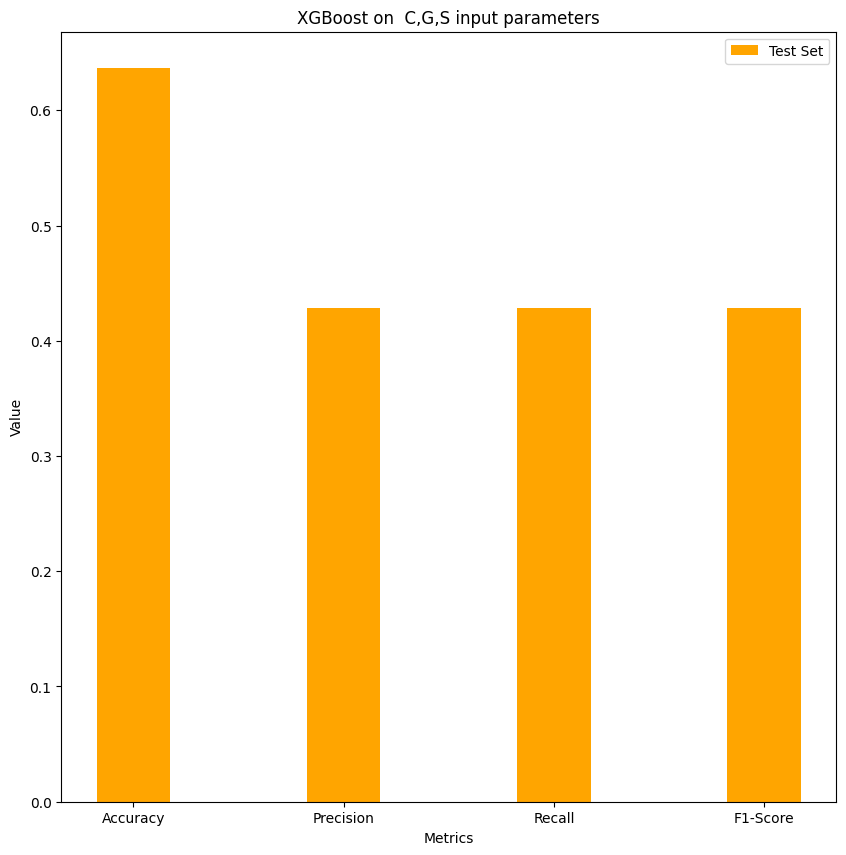

CROSS VALIDATION SCORE = 0.7121212121212122


In [ ]:
results_input_params=evaluate_model(xgboost_input_params,data_X_test_kmeans,data_Y_test_kmeans)
metrics=['Accuracy','Precision','Recall','F1-Score']
x=np.arange(len(metrics))
barwidth=0.35
plt.figure(figsize=(10,10))
# plt.bar(x-barwidth/2,results['validation'],label='Validation Set',color='black',width=0.35)
plt.bar(x,results_input_params['test'],label='Test Set',color='orange',width=0.35)
plt.xticks(x,metrics)
plt.ylabel('Value')
plt.xlabel('Metrics')
plt.title('XGBoost on  C,G,S input parameters')
plt.legend()
plt.show()

crossValScore=cross_val_score(xgboost_input_params,data_X,data_Y_kmeans,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

## XGBoost on all output parameters

In [ ]:
# xgboost_output_params=XGBClassifier()
# gridSearch_tuneParams(xgboost_output_params,param_grid,data_X1_train_kmeans,data_Y1_train_kmeans)

colsample_bytree=0.9, gamma=0, learning_rate=0.6, max_depth=4, n_estimators=180, reg_alpha=0.05, reg_lambda=3, subsample=0.9 - set 1 - 91 % accuracy <br>
'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'reg_alpha': 0.05, 'reg_lambda': 3, 'subsample': 0.8 - set 2 86 %

Fitting 5 folds for each of 12960 candidates, totalling 64800 fits
{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'reg_alpha': 0.05, 'reg_lambda': 3, 'subsample': 0.8}
0.9300653594771242

In [ ]:
xgboost_output_params=XGBClassifier(colsample_bytree=0.9, gamma=0, learning_rate=0.6, max_depth=4, n_estimators=180, reg_alpha=0.05, reg_lambda=3, subsample=0.9)
xgboost_output_params.fit(data_X1_train_kmeans,data_Y1_train_kmeans)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.6, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=180, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      0.71      0.83         7

    accuracy                           0.91        22
   macro avg       0.94      0.86      0.89        22
weighted avg       0.92      0.91      0.90        22

[[15  0]
 [ 2  5]]
Accuracy score =  0.9090909090909091
Precision score =  1.0
Recall score =  0.7142857142857143
F1 score =  0.8333333333333334


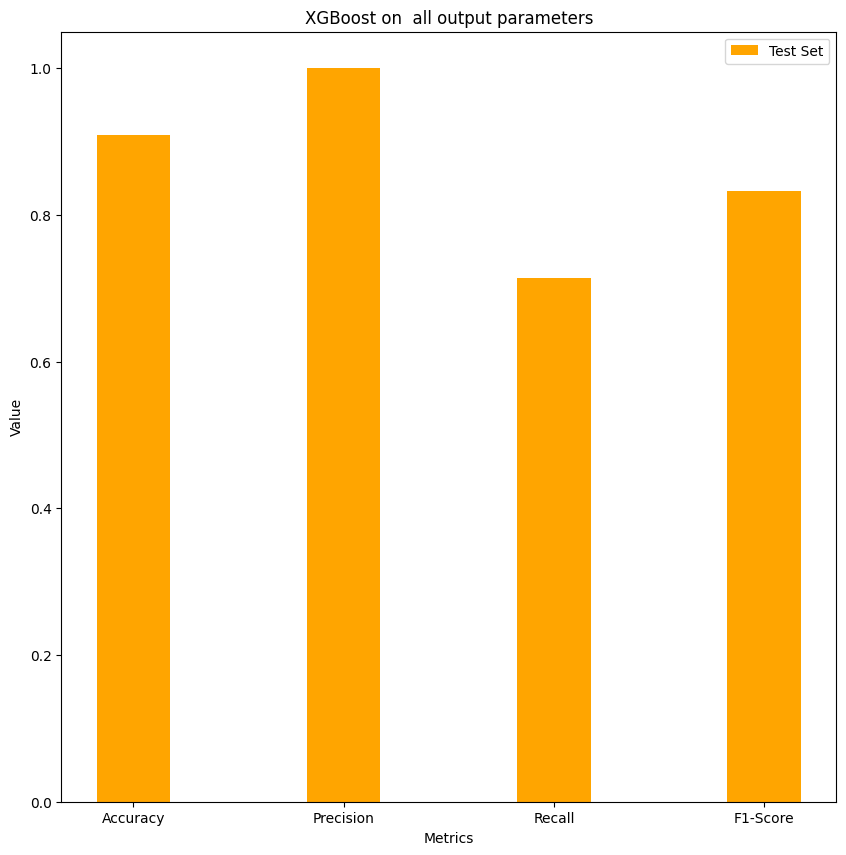

CROSS VALIDATION SCORE = 0.9264069264069266


In [ ]:
results_output_params=evaluate_model(xgboost_output_params,data_X1_test_kmeans,data_Y1_test_kmeans)
metrics=['Accuracy','Precision','Recall','F1-Score']
x=np.arange(len(metrics))
barwidth=0.35
plt.figure(figsize=(10,10))
# plt.bar(x-barwidth/2,results['validation'],label='Validation Set',color='black',width=0.35)
plt.bar(x,results_output_params['test'],label='Test Set',color='orange',width=0.35)
plt.xticks(x,metrics)
plt.ylabel('Value')
plt.xlabel('Metrics')
plt.title('XGBoost on  all output parameters')
plt.legend()
plt.show()

crossValScore=cross_val_score(xgboost_output_params,data_X1,data_Y_kmeans,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

## XGBoost on all parameters

In [ ]:
param_grid = {
    # 'n_estimators': [50, 100, 150, 200], # number of trees
    'n_estimators': [180,190,200], # number of trees
    'max_depth': [4, 5],
    # 'min_child_weight':[1,2],
    'subsample':[0.8,0.9],
    'colsample_bytree':[0.8,0.9],
    # 'max_depth': [2],
    # 'learning_rate': [0.01, 0.1, 0.05],
    # 'learning_rate': [0.08,0.1,0.12],
    'learning_rate': [0.1, 0.2],
    'gamma': [0, 0.05],
    'scale_pos_weight':[1,2,3]
    # 'booster':['gbtree']
    # 'reg_alpha': [0, 0.001, 0.005, 0.05],
    # 'reg_lambda': [1, 2, 3]
}

In [ ]:
# xgboost_all_params=XGBClassifier()
# gridSearch_tuneParams(xgboost_all_params,param_grid,data_X2_train_kmeans,data_Y2_train_kmeans)

Test 1 <br>
Fitting 5 folds for each of 144 candidates, totalling 720 fits
{'gamma': 0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
0.9294117647058824 <br>

Test 2 <br>
Fitting 5 folds for each of 9 candidates, totalling 45 fits
{'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 200}
0.9176470588235294 <br>

Test 3 <br>
Fitting 5 folds for each of 18 candidates, totalling 90 fits
{'booster': 'gbtree', 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 180}
0.9176470588235294 <br>

test 4 <br>
Fitting 5 folds for each of 81 candidates, totalling 405 fits
{'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 180, 'subsample': 0.8}
0.9294117647058824 <br>

test 5 <br>
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
{'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 180, 'subsample': 0.8}
0.9294117647058824 <br>

test 6 <br>
{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 190, 'scale_pos_weight': 3, 'subsample': 0.9}
0.9411764705882352 <br>


In [ ]:
# xgboost_all_params=XGBClassifier(colsample_bytree=0, gamma=0.1, learning_rate=0.3275, max_depth=4, n_estimators=180, reg_alpha=0.05, reg_lambda=1, subsample=0.9)
# xgboost_all_params=XGBClassifier(gamma=0,learning_rate=0.1,max_depth=4,n_estimators=200,eval_metric='error',booster='gbtree')
xgboost_all_params=XGBClassifier(learning_rate=0.2,max_depth=4,n_estimators=190,
                                 eval_metric='error',booster='gbtree',
                                 min_child_weight=1,
                                 colsample_bytree=0.8, subsample=0.9,
                                 gamma=0,
                                 scale_pos_weight=1)

xgboost_all_params.fit(data_X2_train_kmeans,data_Y2_train_kmeans)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=190, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.86      0.92         7

    accuracy                           0.95        22
   macro avg       0.97      0.93      0.95        22
weighted avg       0.96      0.95      0.95        22

[[15  0]
 [ 1  6]]
Accuracy score =  0.9545454545454546
Precision score =  1.0
Recall score =  0.8571428571428571
F1 score =  0.9230769230769231
Accuracy score = 0.9545454545454546


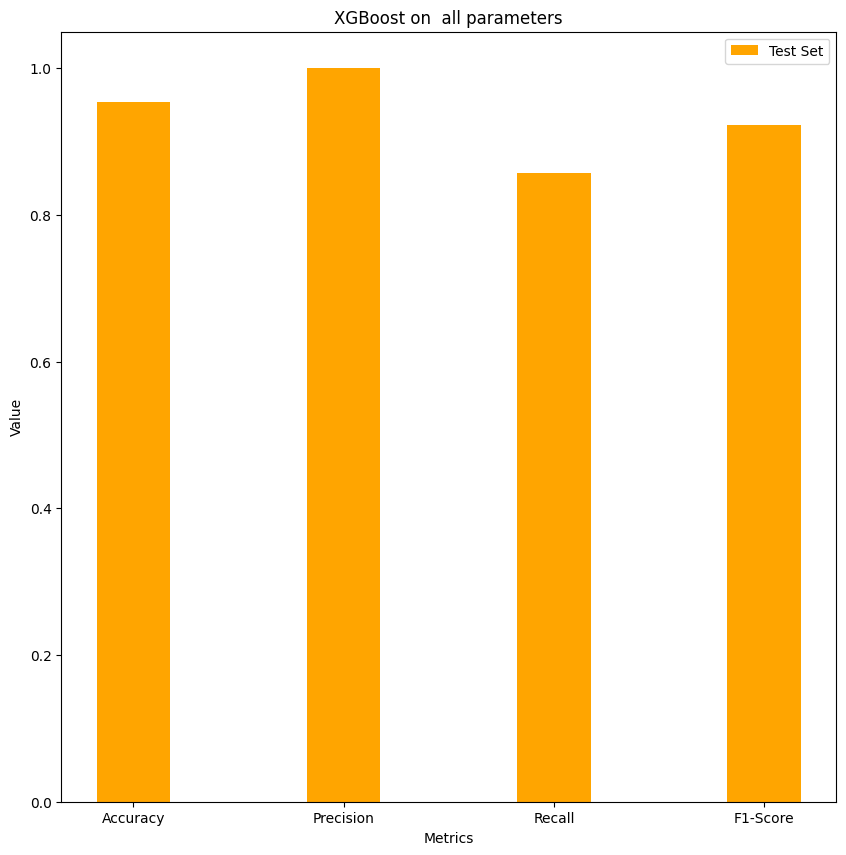

CROSS VALIDATION SCORE = 0.9264069264069266


In [ ]:
results_all_params=evaluate_model(xgboost_all_params,data_X2_test_kmeans,data_Y2_test_kmeans)
print(f'Accuracy score = {results_all_params["test"][0]}')
metrics=['Accuracy','Precision','Recall','F1-Score']
x=np.arange(len(metrics))
barwidth=0.35
plt.figure(figsize=(10,10))
# plt.bar(x-barwidth/2,results['validation'],label='Validation Set',color='black',width=0.35)
plt.bar(x,results_all_params['test'],label='Test Set',color='orange',width=0.35)
plt.xticks(x,metrics)
plt.ylabel('Value')
plt.xlabel('Metrics')
plt.title('XGBoost on  all parameters')
plt.legend()
plt.show()

crossValScore=cross_val_score(xgboost_all_params,data_X2,data_Y_kmeans,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

In [ ]:
# XGBoost

# **XGBoost using KMedoid Dataset**
Classification is performed on C,G and S parameters as well as on all output phenotypes that can be measured once the yield is produced.

## XGBoost on input parameters of kmedoid dataset

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150], # number of trees
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.05],
}

In [ ]:
# xgb=XGBClassifier()
# gridSearch_tuneParams(xgb,param_grid,data_X_train_kmedoid,data_Y_train_kmedoid)

In [ ]:
xgboost_input_params_kmedoid=XGBClassifier(learning_rate=0.05,max_depth=2,n_estimators=150)
xgboost_input_params_kmedoid.fit(data_X_train_kmedoid,data_Y_train_kmedoid)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

              precision    recall  f1-score   support

           0       0.44      0.67      0.53         6
           1       0.85      0.69      0.76        16

    accuracy                           0.68        22
   macro avg       0.65      0.68      0.65        22
weighted avg       0.74      0.68      0.70        22

[[ 4  2]
 [ 5 11]]
Accuracy score =  0.6818181818181818
Precision score =  0.8461538461538461
Recall score =  0.6875
F1 score =  0.7586206896551724
Accuracy score = 0.6818181818181818


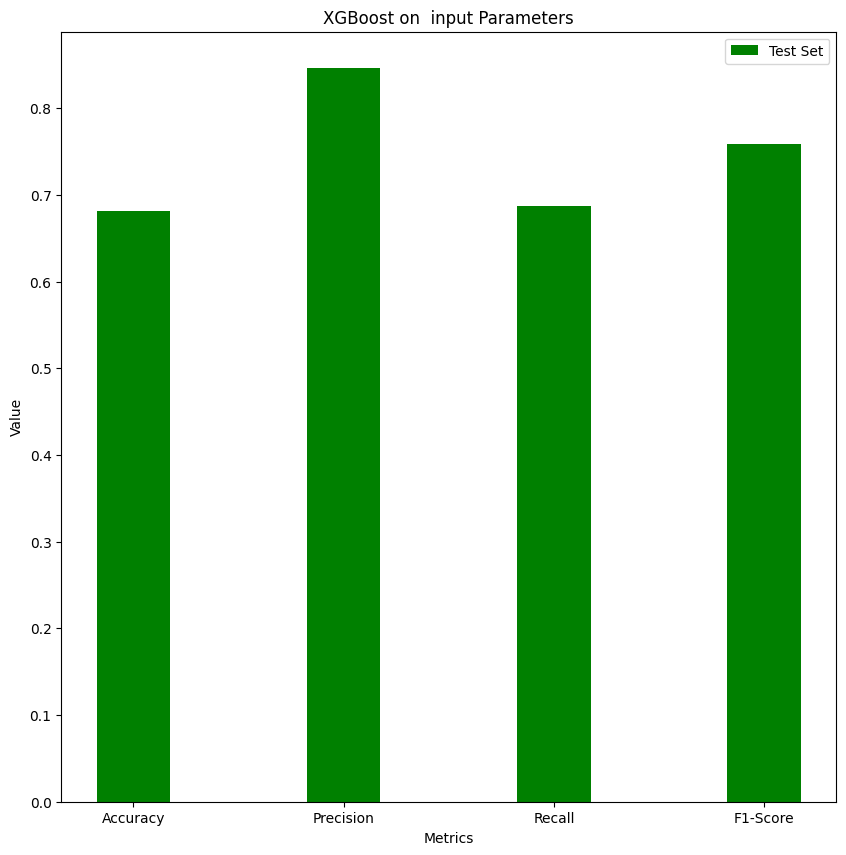

CROSS VALIDATION SCORE = 0.6480519480519481


In [ ]:
results_input_params_kmedoid=evaluate_model(xgboost_input_params_kmedoid,data_X_test_kmedoid,data_Y_test_kmedoid)
print(f'Accuracy score = {results_input_params_kmedoid["test"][0]}')
metrics=['Accuracy','Precision','Recall','F1-Score']
x=np.arange(len(metrics))
barwidth=0.35
plt.figure(figsize=(10,10))
# plt.bar(x-barwidth/2,results['validation'],label='Validation Set',color='black',width=0.35)
plt.bar(x,results_input_params_kmedoid['test'],label='Test Set',color='green',width=0.35)
plt.xticks(x,metrics)
plt.ylabel('Value')
plt.xlabel('Metrics')
plt.title('XGBoost on  input Parameters')
plt.legend()
plt.show()

crossValScore=cross_val_score(xgboost_input_params_kmedoid,data_X,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

## XGBoost on output parameters in kmedoid dataset

In [ ]:
param_grid = {
    'n_estimators': [100, 150, 200], # number of trees
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.1, 0.05],
}

In [ ]:
# xgb=XGBClassifier()
# gridSearch_tuneParams(xgb,param_grid,data_X1_train_kmedoid,data_Y1_train_kmedoid)

In [ ]:
xgboost_output_params_kmedoid=XGBClassifier(learning_rate=0.05,max_depth=2,n_estimators=150)
xgboost_output_params_kmedoid.fit(data_X1_train_kmedoid,data_Y1_train_kmedoid)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.94      0.97        16

    accuracy                           0.95        22
   macro avg       0.93      0.97      0.95        22
weighted avg       0.96      0.95      0.96        22

[[ 6  0]
 [ 1 15]]
Accuracy score =  0.9545454545454546
Precision score =  1.0
Recall score =  0.9375
F1 score =  0.967741935483871


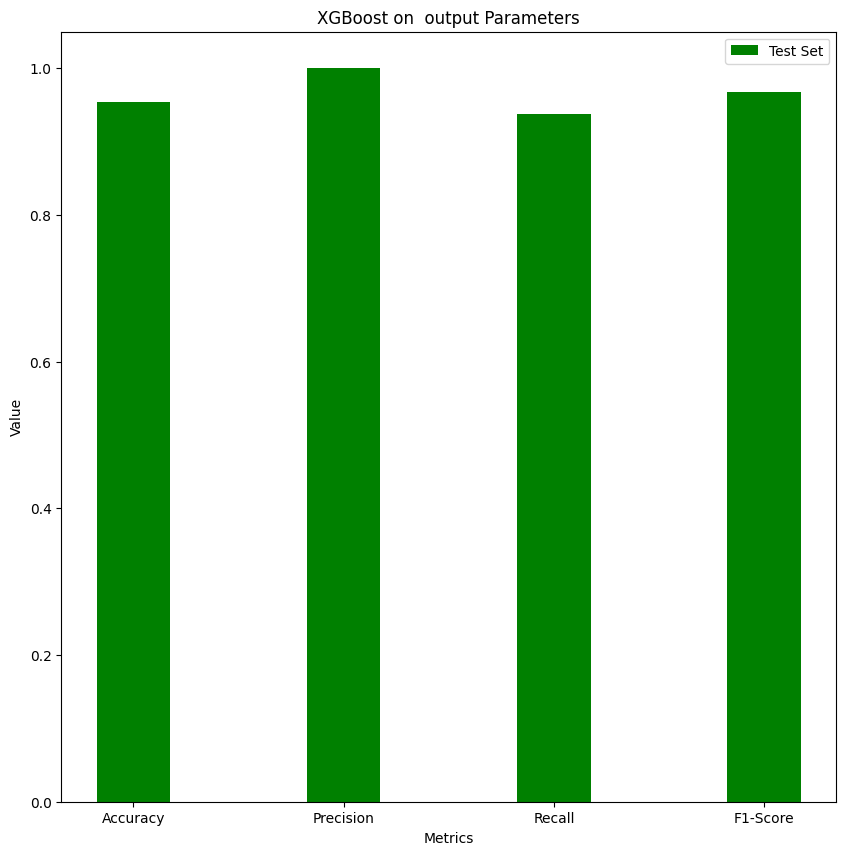

CROSS VALIDATION SCORE = 0.8519480519480519


In [ ]:
results_output_params_kmedoid=evaluate_model(xgboost_output_params_kmedoid,data_X1_test_kmedoid,data_Y1_test_kmedoid)
# print(f'Accuracy score = {results_input_params_kmedoid["test"][0]}')
metrics=['Accuracy','Precision','Recall','F1-Score']
x=np.arange(len(metrics))
barwidth=0.35
plt.figure(figsize=(10,10))
# plt.bar(x-barwidth/2,results['validation'],label='Validation Set',color='black',width=0.35)
plt.bar(x,results_output_params_kmedoid['test'],label='Test Set',color='green',width=0.35)
plt.xticks(x,metrics)
plt.ylabel('Value')
plt.xlabel('Metrics')
plt.title('XGBoost on  output Parameters')
plt.legend()
plt.show()

crossValScore=cross_val_score(xgboost_output_params_kmedoid,data_X1,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

## XGBoost on all parameters

In [ ]:
# param_grid = {
#     'n_estimators': [100, 150, 200], # number of trees
#     'max_depth': [3, 4, 5],
#     'learning_rate': [0.1, 0.05 , 0.15],
# }

param_grid = {
    # 'n_estimators': [50, 100, 150, 200], # number of trees
    'n_estimators': [100,150,200, 250], # number of trees
    'max_depth': [2,3,4,5],
    # 'min_child_weight':[1,2],
    # 'subsample':[0.8,0.9],
    # 'colsample_bytree':[0.8,0.9],
    # 'max_depth': [2],
    # 'learning_rate': [0.01, 0.1, 0.05],
    # 'learning_rate': [0.08,0.1,0.12],
    'learning_rate': [0.1, 0.15, 0.2, 0.25],
    # 'gamma': [0, 0.05],
    # 'scale_pos_weight':[1,2,3]
    # 'booster':['gbtree']
    # 'reg_alpha': [0, 0.001, 0.005, 0.05],
    # 'reg_lambda': [1, 2, 3]
}

In [ ]:
xgb=XGBClassifier()
gridSearch_tuneParams(xgb,param_grid,data_X2_train_kmedoid,data_Y2_train_kmedoid)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
{'learning_rate': 0.25, 'max_depth': 4, 'n_estimators': 150}
0.8718954248366012


Test 1 <br>
Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
0.8601307189542482 <br>
Test 2 <br>
Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 200}
0.8954248366013072 <br>
test 3 <br>
Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
0.8954248366013072 <br>
cross-val-score = CROSS VALIDATION SCORE = 0.861038961038961 <br>
test 4 <br>
Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}
0.8954248366013072 <br>
CROSS VALIDATION SCORE = 0.8796536796536797<br>

test 5 <br>
Fitting 5 folds for each of 64 candidates, totalling 320 fits
{'learning_rate': 0.25, 'max_depth': 4, 'n_estimators': 150}
0.8718954248366012<br>
CROSS VALIDATION SCORE = 0.8891774891774892<br>



In [ ]:
# xgboost_all_params_kmedoid=XGBClassifier(learning_rate=0.1,max_depth=4,n_estimators=150)
xgboost_all_params_kmedoid=XGBClassifier(learning_rate=0.25,max_depth=4,n_estimators=200)

xgboost_all_params_kmedoid.fit(data_X2_train_kmedoid,data_Y2_train_kmedoid)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.25, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.94      0.97        16

    accuracy                           0.95        22
   macro avg       0.93      0.97      0.95        22
weighted avg       0.96      0.95      0.96        22

[[ 6  0]
 [ 1 15]]
Accuracy score =  0.9545454545454546
Precision score =  1.0
Recall score =  0.9375
F1 score =  0.967741935483871


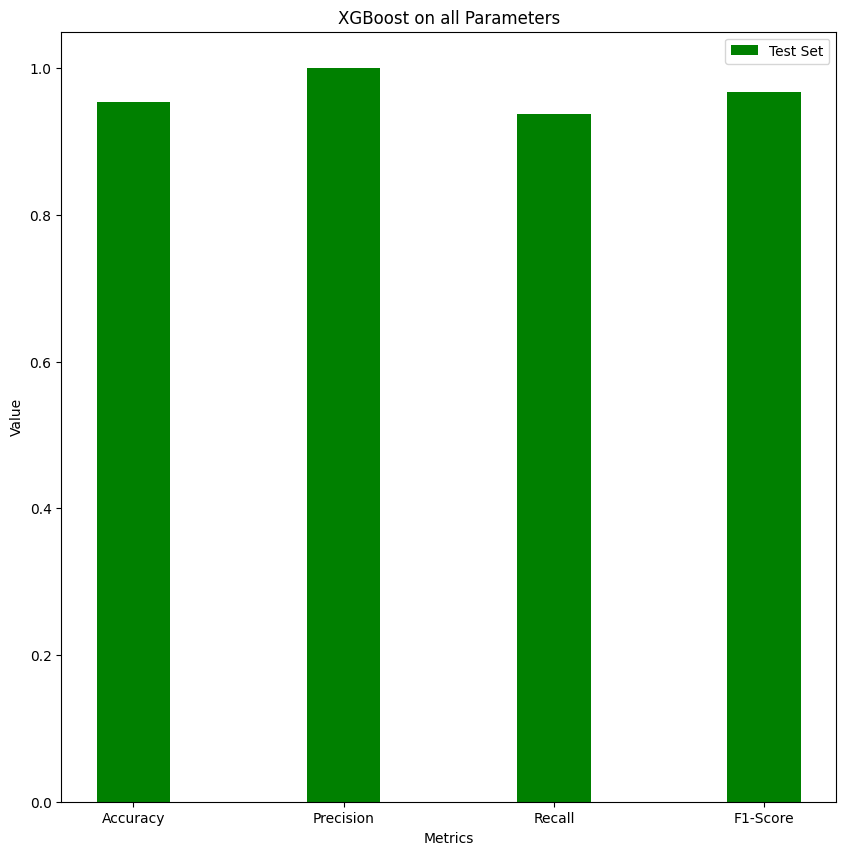

CROSS VALIDATION SCORE = 0.8891774891774892


In [ ]:
results_all_params_kmedoid=evaluate_model(xgboost_all_params_kmedoid,data_X2_test_kmedoid,data_Y2_test_kmedoid)
# print(f'Accuracy score = {results_input_params_kmedoid["test"][0]}')
metrics=['Accuracy','Precision','Recall','F1-Score']
x=np.arange(len(metrics))
barwidth=0.35
plt.figure(figsize=(10,10))
# plt.bar(x-barwidth/2,results['validation'],label='Validation Set',color='black',width=0.35)
plt.bar(x,results_all_params_kmedoid['test'],label='Test Set',color='green',width=0.35)
plt.xticks(x,metrics)
plt.ylabel('Value')
plt.xlabel('Metrics')
plt.title('XGBoost on all Parameters')
plt.legend()
plt.show()

crossValScore=cross_val_score(xgboost_all_params_kmedoid,data_X2,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

### Hyperparameter tuning for all parameters model
We are using GridSearchCV for finding the optimal parameters

We start with tuning max_depth and min_child_weight since they have the most impact on the model

In [ ]:
seed = 100
n_estimators = 100
learning_rate = 0.1
gamma = 0
subsample = 0.8
colsample_bytree = 0.8
reg_alpha = 1
reg_lambda = 1
silent = False

param_grid={'max_depth':range(1,9),'min_child_weight':range(1,4,1)}


# instantiating the model
xgb = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, gamma=gamma, subsample=subsample,
                    colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,seed=seed)
gs=GridSearchCV(xgb,param_grid,cv=5,scoring='accuracy')
gs.fit(data_X2_train_kmedoid,data_Y2_train_kmedoid)
print(gs.best_params_)
print(gs.best_score_)

max_depth=gs.best_params_['max_depth']
min_child_weight=gs.best_params_['min_child_weight']

{'max_depth': 6, 'min_child_weight': 1}
0.8836601307189541


Test 1
max_depth = 7 , min_child_weight =1 <br>
Test 2
max_depth = 6, min_child_weight=1 <br>
Test 3
max_depth = 6, min_child_weight=1 <br>

In [ ]:
gs.best_estimator_.score(data_X2_test_kmedoid,data_Y2_test_kmedoid)

0.9545454545454546

In [ ]:
crossValScore=cross_val_score(gs.best_estimator_,data_X2,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

CROSS VALIDATION SCORE = 0.8242424242424242


In [ ]:
parameters = {}
parameters['seed'] = seed
parameters['n_estimators'] = n_estimators
parameters['learning_rate'] = learning_rate
parameters['gamma'] = gamma
parameters['colsample_bytree'] = colsample_bytree
parameters['reg_alpha'] = reg_alpha
parameters['reg_lambda'] = reg_lambda
parameters['silent'] = silent
parameters['max_depth'] = max_depth
parameters['min_child_weight'] = min_child_weight
parameters['subsample'] = subsample

### tuning gamma parameter

In [ ]:
param_grid={'gamma':[i/10.0 for i in range(0,10)]}
xgb = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, subsample=subsample,
                    colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,seed=seed,max_depth=max_depth, min_child_weight=min_child_weight)
gs=GridSearchCV(xgb,param_grid,cv=5,scoring='accuracy')
gs.fit(data_X2_train_kmedoid,data_Y2_train_kmedoid)
print(gs.best_params_)
print(gs.best_score_)

{'gamma': 0.0}
0.8836601307189541


In [ ]:
gamma=gs.best_params_['gamma']
parameters['gamma']=gamma
gs.best_estimator_.score(data_X2_test_kmedoid,data_Y2_test_kmedoid)

0.9545454545454546

In [ ]:
crossValScore=cross_val_score(gs.best_estimator_,data_X2,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

CROSS VALIDATION SCORE = 0.8242424242424242


Tuning the colsample and subsample

In [ ]:
param_grid3 = {
 'subsample':[i/10.0 for i in range(6,10)],
 'colsample_bytree':[i/10.0 for i in range(6,10)]
}
xgb = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, subsample=subsample,
                    colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,seed=seed,max_depth=max_depth, min_child_weight=min_child_weight, gamma=gamma)
gs=GridSearchCV(xgb,param_grid3,cv=5,scoring='accuracy')
gs.fit(data_X2_train_kmedoid,data_Y2_train_kmedoid)
print(gs.best_params_)
print(gs.best_score_)

{'colsample_bytree': 0.7, 'subsample': 0.6}
0.8947712418300654


In [ ]:
colsample_bytree=gs.best_params_['colsample_bytree']
subsample=gs.best_params_['subsample']
parameters['colsample_bytree']=colsample_bytree
parameters['subsample']=subsample

gs.best_estimator_.score(data_X2_test_kmedoid,data_Y2_test_kmedoid)


0.9545454545454546

In [ ]:
crossValScore=cross_val_score(gs.best_estimator_,data_X2,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

CROSS VALIDATION SCORE = 0.8606060606060606


### We see an improvement in the cross validation score from 82 to 86

we tune regularization parameters to reduce overfitting

In [ ]:
param_grid4 = {
 'reg_alpha':[0.001,0.01,0.1]
}
xgb = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, subsample=subsample,
                    colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,seed=seed,max_depth=max_depth, min_child_weight=min_child_weight, gamma=gamma)
gs=GridSearchCV(xgb,param_grid4,cv=5,scoring='accuracy')
gs.fit(data_X2_train_kmedoid,data_Y2_train_kmedoid)
print(gs.best_params_)
print(gs.best_score_)

{'reg_alpha': 0.001}
0.8947712418300654


In [ ]:
reg_alpha=gs.best_params_['reg_alpha']
parameters['reg_alpha']=reg_alpha
gs.best_estimator_.score(data_X2_test_kmedoid,data_Y2_test_kmedoid)

1.0

In [ ]:
crossValScore=cross_val_score(gs.best_estimator_,data_X2,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

CROSS VALIDATION SCORE = 0.8701298701298701


### Cross validation score improved from 86 to 87

In [ ]:
param_grid5 = {
 'reg_alpha':[0, 0.001, 0.005, 0.01, 0.05],
 'reg_lambda':[0,0.001,0.005,5e-5,5e-6]
}
xgb = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, subsample=subsample,
                    colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,seed=seed,max_depth=max_depth, min_child_weight=min_child_weight, gamma=gamma)
gs=GridSearchCV(xgb,param_grid5,cv=5,scoring='accuracy')
gs.fit(data_X2_train_kmedoid,data_Y2_train_kmedoid)
print(gs.best_params_)
print(gs.best_score_)

{'reg_alpha': 0, 'reg_lambda': 0.005}
0.9183006535947712


In [ ]:
reg_alpha=gs.best_params_['reg_alpha']
reg_lambda=gs.best_params_['reg_lambda']
parameters['reg_alpha']=reg_alpha
parameters['reg_lambda']=reg_lambda
gs.best_estimator_.score(data_X2_test_kmedoid,data_Y2_test_kmedoid)

0.9090909090909091

In [ ]:
crossValScore=cross_val_score(gs.best_estimator_,data_X2,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

CROSS VALIDATION SCORE = 0.8887445887445887


In [ ]:
parameters

{'seed': 100,
 'n_estimators': 100,
 'learning_rate': 0.1,
 'gamma': 0.0,
 'colsample_bytree': 0.7,
 'reg_alpha': 0,
 'reg_lambda': 0.005,
 'silent': False,
 'max_depth': 6,
 'min_child_weight': 1,
 'subsample': 0.6}

In [ ]:
param_grid6={
    'learning_rate':[0.05,0.065,0.075,0.079,0.08,0.09,0.1]
}
xgb = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, subsample=subsample,
                    colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,seed=seed,max_depth=max_depth, min_child_weight=min_child_weight, gamma=gamma)
gs=GridSearchCV(xgb,param_grid6,cv=5,scoring='accuracy')
gs.fit(data_X2_train_kmedoid,data_Y2_train_kmedoid)
print(gs.best_params_)
print(gs.best_score_)

{'learning_rate': 0.075}
0.8947712418300654


In [ ]:
learning_rate=gs.best_params_['learning_rate']
parameters['learning_rate']=learning_rate
gs.best_estimator_.score(data_X2_test_kmedoid,data_Y2_test_kmedoid)

1.0

In [ ]:
crossValScore=cross_val_score(gs.best_estimator_,data_X2,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

CROSS VALIDATION SCORE = 0.8701298701298701


In [ ]:
parameters

{'seed': 100,
 'n_estimators': 100,
 'learning_rate': 0.075,
 'gamma': 0.0,
 'colsample_bytree': 0.7,
 'reg_alpha': 0,
 'reg_lambda': 0.005,
 'silent': False,
 'max_depth': 6,
 'min_child_weight': 1,
 'subsample': 0.6}

In [ ]:
xgboost_all_params_kmedoid_tuned=XGBClassifier(n_estimators=100, learning_rate=0.075, subsample=0.6,
                    colsample_bytree=0.7, reg_alpha=0, reg_lambda=0.005,seed=100,max_depth=6, gamma=0, min_child_weight=1,
                                               eval_metric='error',booster='gbtree')
xgboost_all_params_kmedoid_tuned.fit(data_X2_train_kmedoid,data_Y2_train_kmedoid)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.075, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        16

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22

[[ 6  0]
 [ 0 16]]
Accuracy score =  1.0
Precision score =  1.0
Recall score =  1.0
F1 score =  1.0


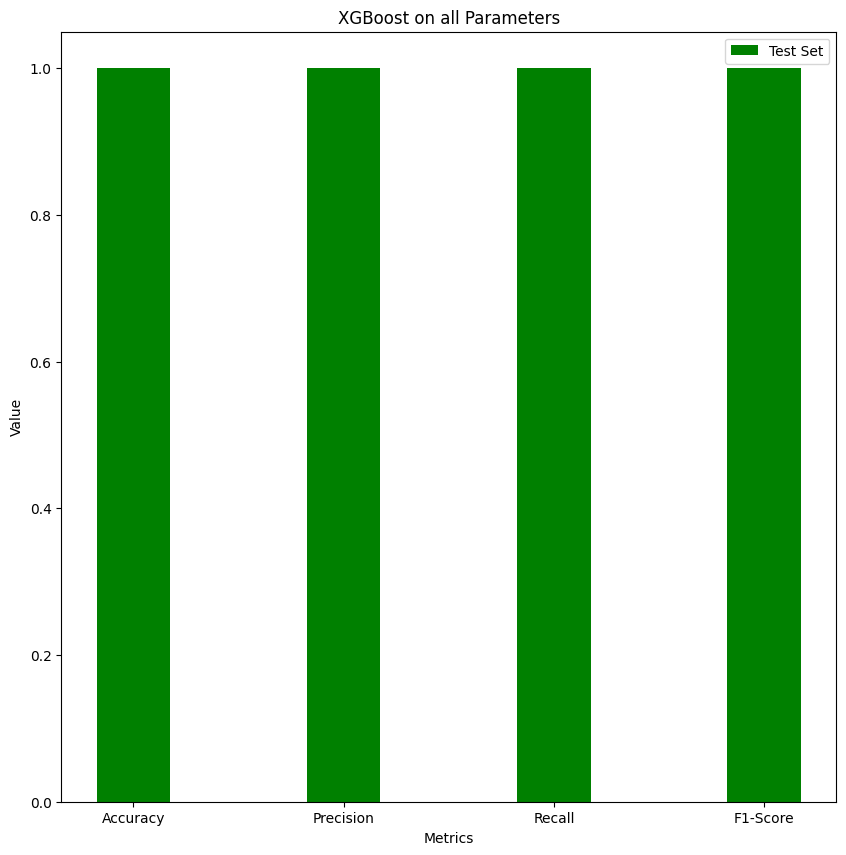

CROSS VALIDATION SCORE = 0.8792207792207792


In [ ]:
results_all_params_kmedoid_tuned=evaluate_model(xgboost_all_params_kmedoid_tuned,data_X2_test_kmedoid,data_Y2_test_kmedoid)
# print(f'Accuracy score = {results_input_params_kmedoid["test"][0]}')
metrics=['Accuracy','Precision','Recall','F1-Score']
x=np.arange(len(metrics))
barwidth=0.35
plt.figure(figsize=(10,10))
# plt.bar(x-barwidth/2,results['validation'],label='Validation Set',color='black',width=0.35)
plt.bar(x,results_all_params_kmedoid_tuned['test'],label='Test Set',color='green',width=0.35)
plt.xticks(x,metrics)
plt.ylabel('Value')
plt.xlabel('Metrics')
plt.title('XGBoost on all Parameters')
plt.legend()
plt.show()

crossValScore=cross_val_score(xgboost_all_params_kmedoid_tuned,data_X2,data_Y_kmedoid,cv=5,scoring='accuracy')
print(f'CROSS VALIDATION SCORE = {crossValScore.mean()}')

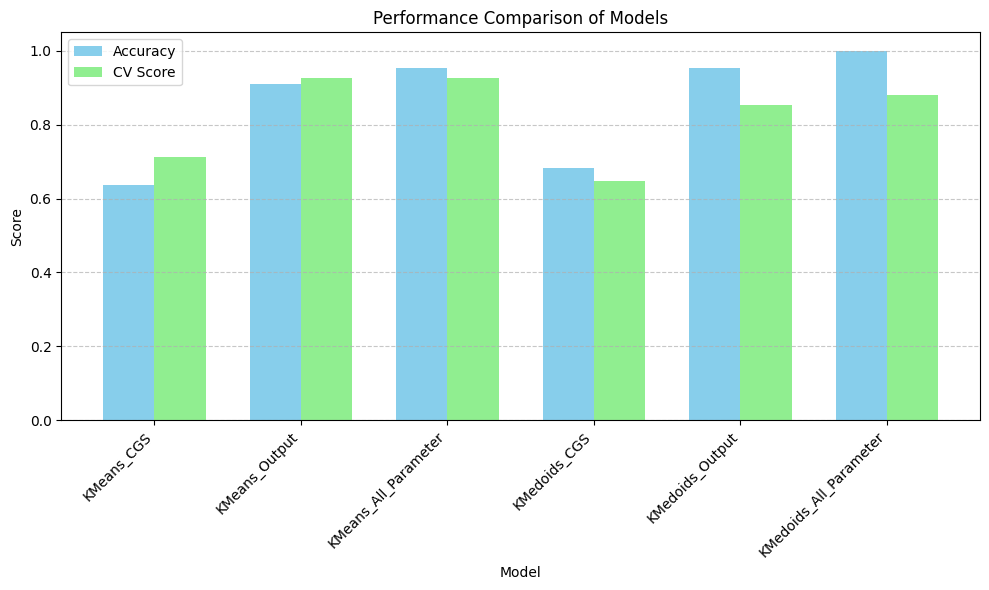

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_names = [
    "KMeans_CGS",
    "KMeans_Output",
    "KMeans_All_Parameter",
    "KMedoids_CGS",
    "KMedoids_Output",
    "KMedoids_All_Parameter"
]


accuracy_scores = [0.6363636363636364, 0.9090909090909091, 0.9545454545454546, 0.6818181818181818, 0.9545454545454546, 1.0]
cv_scores = [0.7121212121212122, 0.9264069264069266, 0.9264069264069266, 0.6480519480519481, 0.8519480519480519, 0.8792207792207792]

results = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_scores,
    "CV Score": cv_scores
})



x = np.arange(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

rects1 = ax.bar(x - width/2, results['Accuracy'], width, label='Accuracy', color='skyblue')


rects2 = ax.bar(x + width/2, results['CV Score'], width, label='CV Score', color='lightgreen')

ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_title('Performance Comparison of Models')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()